In [ ]:
import numpy as np 
import pandas as pd

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/competitions/spaceship-titanic/sample_submission.csv
/kaggle/input/competitions/spaceship-titanic/train.csv
/kaggle/input/competitions/spaceship-titanic/test.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
train = pd.read_csv("/kaggle/input/competitions/spaceship-titanic/train.csv")

In [4]:
train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


### Data Exploration

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [6]:
categorical_features = train.select_dtypes(include = [object])

In [7]:
categorical_features.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,VIP,Name
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,False,Maham Ofracculy
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,False,Juanna Vines
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,True,Altark Susent
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,False,Solam Susent
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,False,Willy Santantines


In [8]:
numerical_features = train.select_dtypes(include = [np.number])
numerical_features.head()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
0,39.0,0.0,0.0,0.0,0.0,0.0
1,24.0,109.0,9.0,25.0,549.0,44.0
2,58.0,43.0,3576.0,0.0,6715.0,49.0
3,33.0,0.0,1283.0,371.0,3329.0,193.0
4,16.0,303.0,70.0,151.0,565.0,2.0


In [9]:
print(numerical_features.columns)
    

Index(['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck'], dtype='object')


In [10]:
numerical_features.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


The spending-related features are extremely right-skewed. Most passengers have zero or very low expenditure, as indicated by a median of 0 across all spending columns, while a small number of passengers have exceptionally high spending values. This results in a long right tail and the presence of extreme outliers.

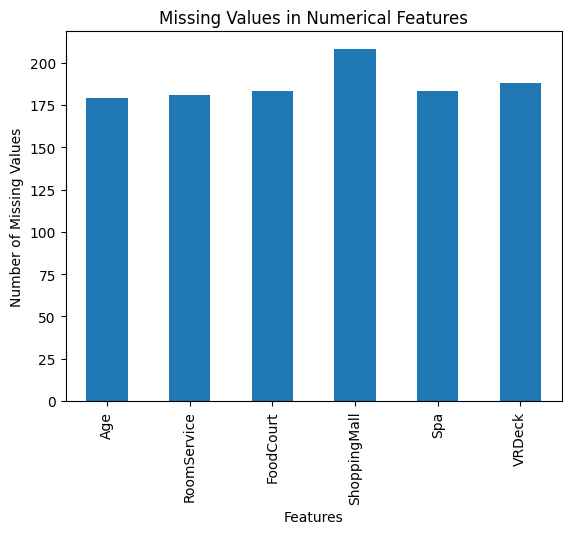

In [11]:
#Distribution of null values for numerical_features
missing_values = numerical_features.isnull().sum()

missing_values.plot(kind='bar')

plt.title('Missing Values in Numerical Features')
plt.xlabel('Features')
plt.ylabel('Number of Missing Values')

plt.show()


**We need an imputation strategy for these features. For this we first need to visualize the distributions.**

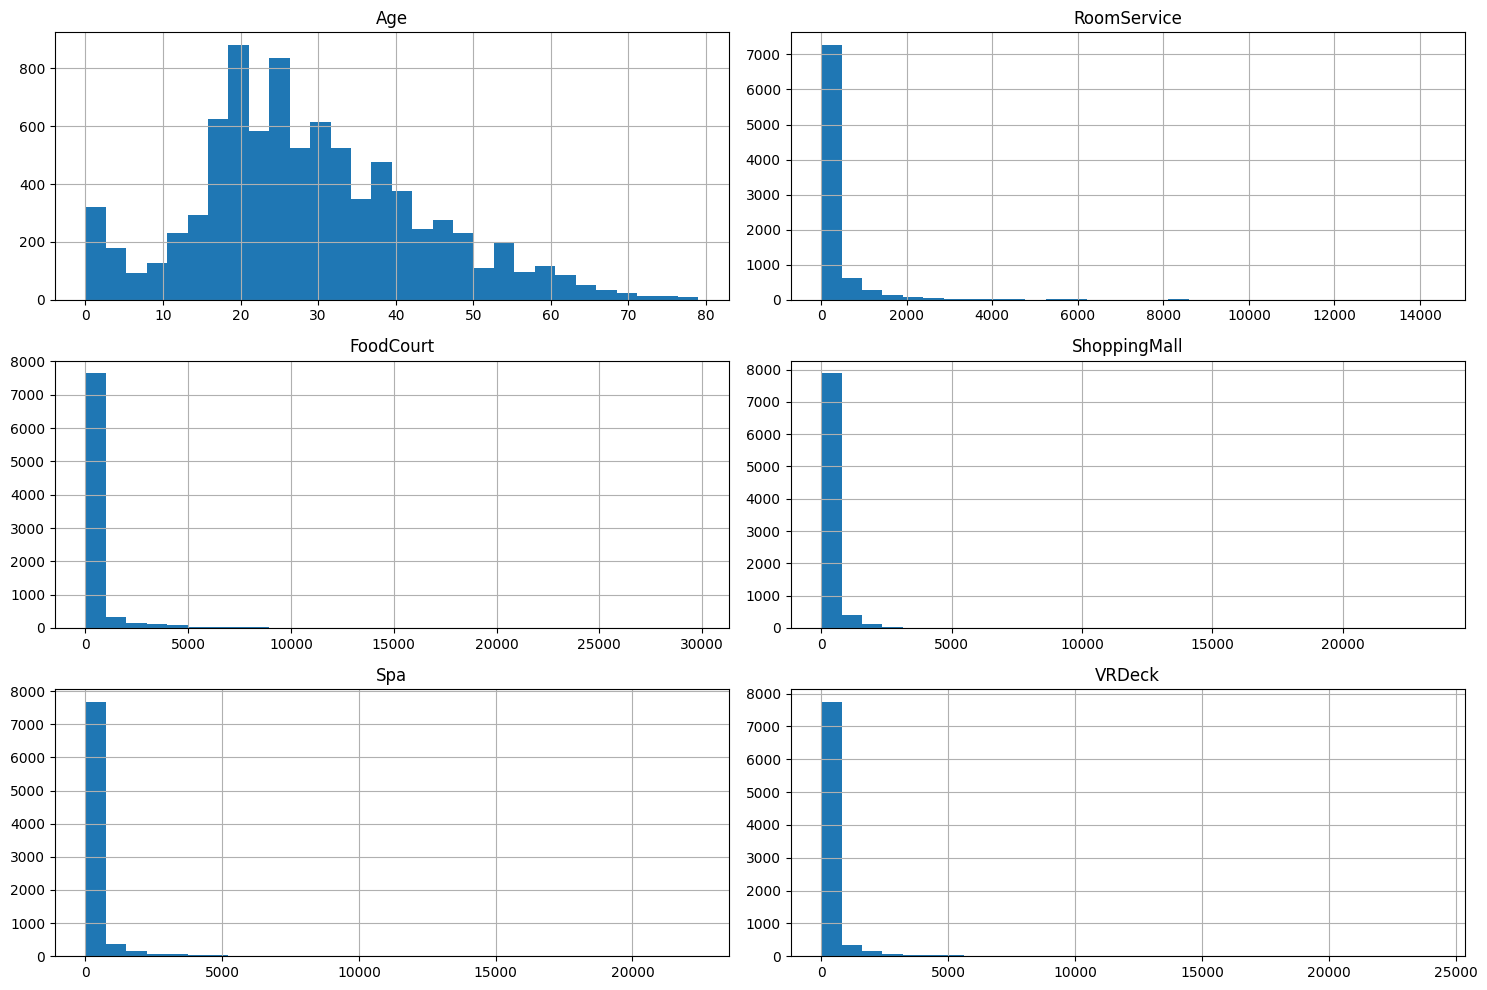

In [12]:
#distribution for numerical_features
numerical_features.hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()

**It appears all the spending columns are extremely right skewed. It appears it is better to use median for imputation for these.**

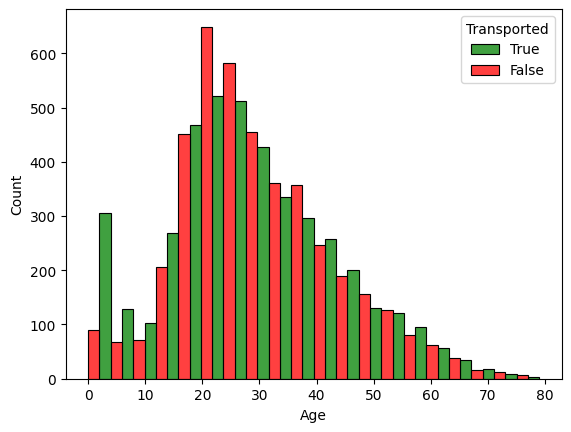

In [13]:
#Distribution of Age for transported
sns.histplot(
    data=train,
    x='Age',
    hue='Transported',
    bins=20,
    palette={True: 'green', False: 'red'},
    multiple='dodge'
)

plt.legend(
    title='Transported',
    labels=['True', 'False']
)

plt.show()

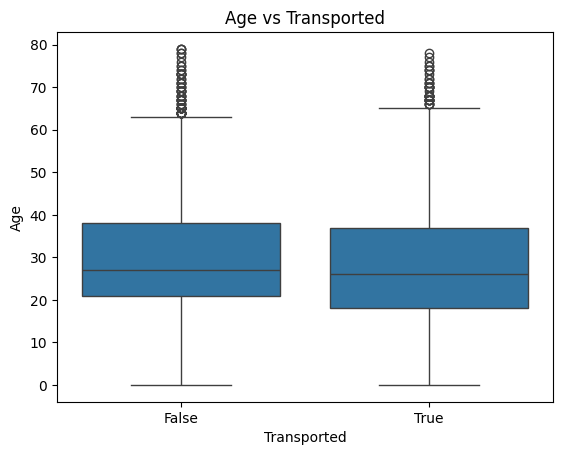

In [14]:
sns.boxplot(
    data=train,
    x='Transported',
    y='Age'
)

plt.title('Age vs Transported')
plt.show()

In [15]:
train.groupby('Transported')['Age'].agg(['mean', 'median'])

,mean,median
Transported,,
False,29.922858,27.0
True,27.748834,26.0


Age on its own appears to have a relatively weak relationship with the target. The average age differs by only around two years between transported and non-transported passengers, suggesting that age alone may not be a strong predictor of transportation status.

In [16]:
#Creating a total spending column
spending_cols = [
    'RoomService',
    'FoodCourt',
    'ShoppingMall',
    'Spa',
    'VRDeck'
]

train['TotalSpend'] = train[spending_cols].sum(axis=1)

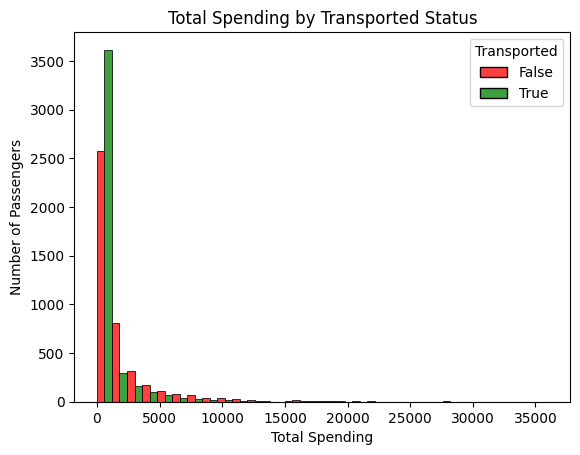

In [17]:
sns.histplot(
    data=train,
    x='TotalSpend',
    hue='Transported',
    bins=30,
    palette={True: 'green', False: 'red'},
    multiple='dodge'
)

plt.title('Total Spending by Transported Status')
plt.xlabel('Total Spending')
plt.ylabel('Number of Passengers')

plt.show()

In [18]:
pd.pivot_table(train,index='Transported',values= 'TotalSpend')

,TotalSpend
Transported,
False,2004.149247
True,885.689127


In [19]:
train.pivot_table(
    values='TotalSpend',
    index='Transported',
    aggfunc='median'
)

,TotalSpend
Transported,
False,907.0
True,0.0


In [20]:
train.groupby('Transported')['TotalSpend'].apply(
    lambda x: (x == 0).mean()
)

Transported
False    0.180765
True     0.656236
Name: TotalSpend, dtype: float64

**It appears among zero spenders most of them were transported**

In [21]:
positive_spend= train[train['TotalSpend'] > 0]

positive_spend.groupby('Transported')['TotalSpend'].quantile(
    [0.25, 0.5, 0.75]
)

Transported      
False        0.25     792.0
             0.50    1182.0
             0.75    2578.0
True         0.25     804.0
             0.50    1262.0
             0.75    2973.0
Name: TotalSpend, dtype: float64

**The strongest relationship between total spending and transportation appears to be whether a passenger spent anything at all, rather than the exact amount spent. Among passengers with positive spending, the spending distributions are relatively similar, although transported passengers have slightly higher median and upper-quartile spending.**

We can later create a new feature of hasSpent

<Axes: >

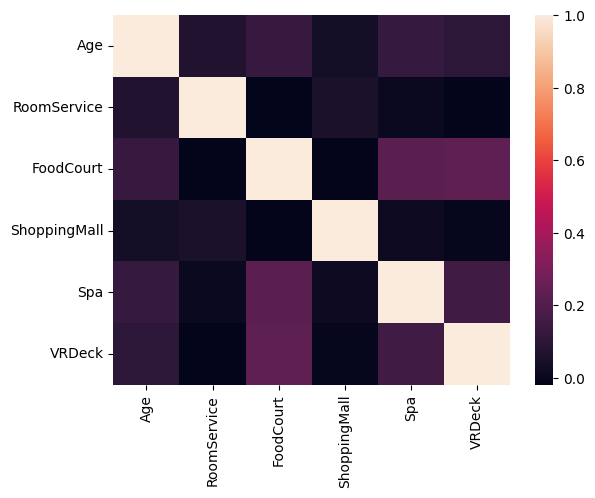

In [22]:
sns.heatmap(numerical_features.corr())

None of the numerical features have a strong linear relationship with each other.

### Categorical Features

In [23]:
for feature in categorical_features:
    if train[feature].nunique() <= 10:
        print(f"For {feature}: {train[feature].value_counts()}")

For HomePlanet: HomePlanet
Earth     4602
Europa    2131
Mars      1759
Name: count, dtype: int64
For CryoSleep: CryoSleep
False    5439
True     3037
Name: count, dtype: int64
For Destination: Destination
TRAPPIST-1e      5915
55 Cancri e      1800
PSO J318.5-22     796
Name: count, dtype: int64
For VIP: VIP
False    8291
True      199
Name: count, dtype: int64


In [24]:
train['Transported'].value_counts(normalize=True)

Transported
True     0.503624
False    0.496376
Name: proportion, dtype: float64

Target Feature appears to be balanced and so we do not need to balance any categories

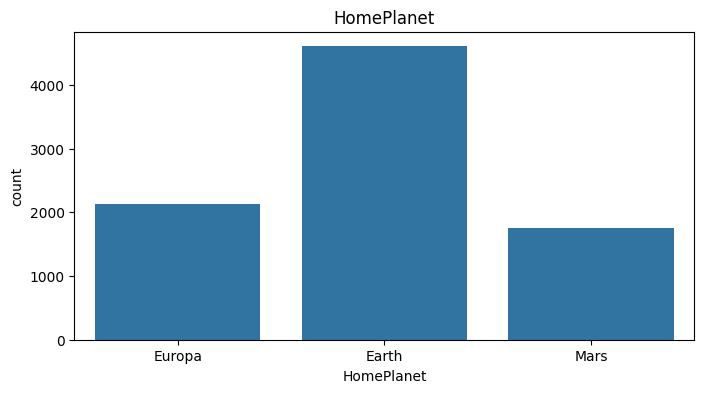

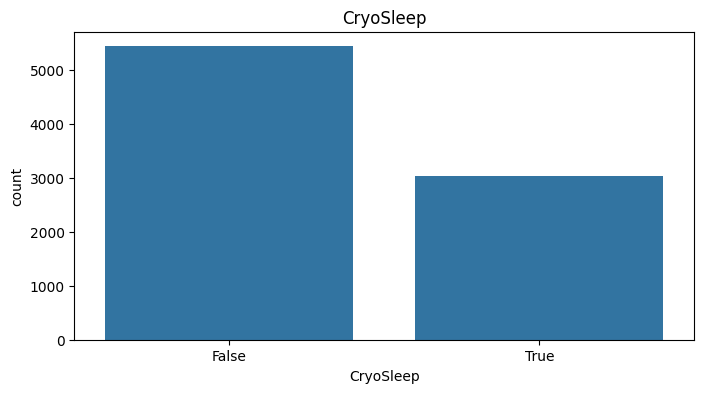

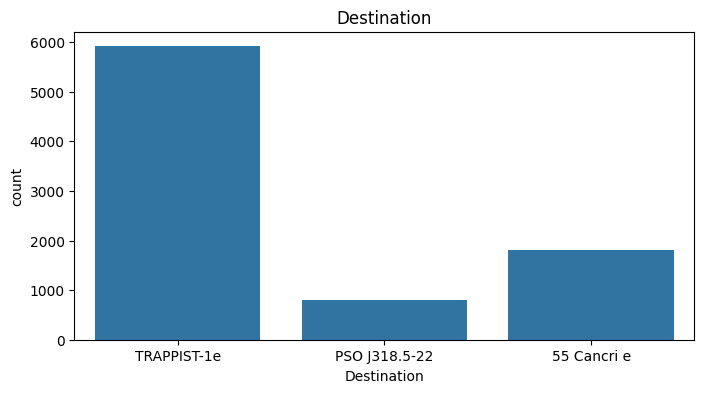

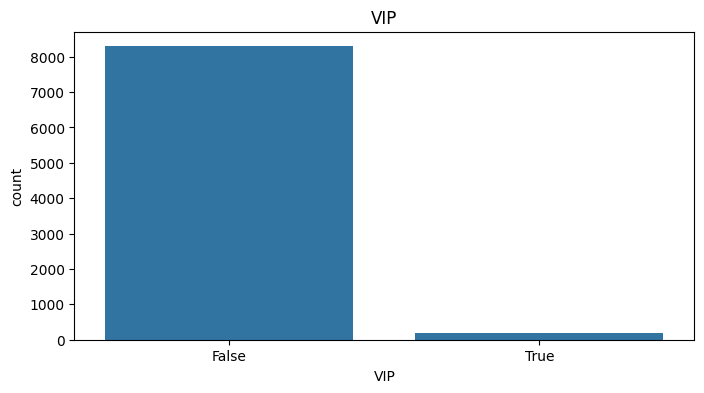

In [25]:
for feature in categorical_features:
    if train[feature].nunique() <= 10:
        plt.figure(figsize=(8, 4))
        sns.countplot(data=train, x=feature)
        plt.title(feature)
        plt.show()

In [26]:
print(pd.pivot_table(train,index='Transported',columns='HomePlanet',values='PassengerId' ,aggfunc='count'))


HomePlanet   Earth  Europa  Mars
Transported                     
False         2651     727   839
True          1951    1404   920


Most of the people from europa were transported

In [27]:
pd.crosstab(
    train['HomePlanet'],
    train['Transported'],
    normalize='index'
)

Transported,False,True
HomePlanet,,
Earth,0.576054,0.423946
Europa,0.341154,0.658846
Mars,0.476976,0.523024


In [28]:
print(pd.pivot_table(train,index='Transported',columns='CryoSleep',values='PassengerId',aggfunc='count'))
pd.crosstab(
    train['CryoSleep'],
    train['Transported'],
    normalize='index'
)

CryoSleep    False  True 
Transported              
False         3650    554
True          1789   2483


Transported,False,True
CryoSleep,,
False,0.671079,0.328921
True,0.182417,0.817583


Most of the people that were in cryosleep were transported. There appears to be a very strong relationship

In [29]:
print(pd.pivot_table(train,index='Transported',columns='Destination',values='PassengerId',aggfunc='count'))
pd.crosstab(
    train['Destination'],
    train['Transported'],
    normalize='index'
)

Destination  55 Cancri e  PSO J318.5-22  TRAPPIST-1e
Transported                                         
False                702            395         3128
True                1098            401         2787


Transported,False,True
Destination,,
55 Cancri e,0.390000,0.610000
PSO J318.5-22,0.496231,0.503769
TRAPPIST-1e,0.528825,0.471175


In [30]:
print(pd.pivot_table(train,index='Transported',columns='VIP',values='PassengerId',aggfunc='count'))
pd.crosstab(
    train['VIP'],
    train['Transported'],
    normalize='index'
)

VIP          False  True 
Transported              
False         4093    123
True          4198     76


Transported,False,True
VIP,,
False,0.493668,0.506332
True,0.618090,0.381910


Most of the VIP were not transported

In [31]:
#Exploring passenger group
train['Group'] = train['PassengerId'].str.split('_').str[0]
train['Group'].head(10)

0    0001
1    0002
2    0003
3    0003
4    0004
5    0005
6    0006
7    0006
8    0007
9    0008
Name: Group, dtype: object

In [32]:
train['Group'].describe()

count     8693
unique    6217
top       9081
freq         8
Name: Group, dtype: object

In [33]:
train['GroupSize'] = train.groupby('Group')['Group'].transform('count')

In [34]:
train[['Group','GroupSize']].head()

,Group,GroupSize
0,0001,1
1,0002,1
2,0003,2
3,0003,2
4,0004,1


In [35]:
train['GroupSize'].value_counts().sort_index()

GroupSize
1    4805
2    1682
3    1020
4     412
5     265
6     174
7     231
8     104
Name: count, dtype: int64

Transported     False     True 
GroupSize                      
1            0.547555  0.452445
2            0.461950  0.538050
3            0.406863  0.593137
4            0.359223  0.640777
5            0.407547  0.592453
6            0.385057  0.614943
7            0.458874  0.541126
8            0.605769  0.394231


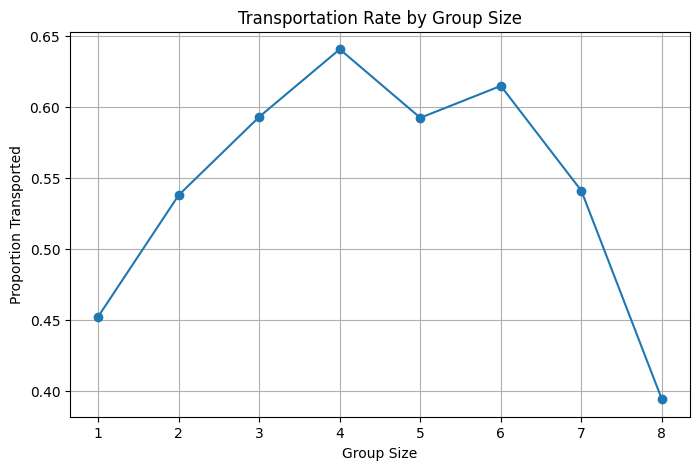

In [36]:
group_transport = pd.crosstab(
    train['GroupSize'],
    train['Transported'],
    normalize='index'
)
print(group_transport)
plt.figure(figsize=(8, 5))

plt.plot(
    group_transport.index,
    group_transport[True],
    marker='o'
)

plt.title('Transportation Rate by Group Size')
plt.xlabel('Group Size')
plt.ylabel('Proportion Transported')

plt.xticks(group_transport.index)
plt.grid(True)

plt.show()

Passengers traveling in groups tend to have a higher transportation rate than passengers traveling alone, although the relationship is non-linear.

In [37]:
# Exploring cabin
train[['Deck', 'CabinNum', 'Side']] = train['Cabin'].str.split('/', expand=True)

In [38]:
train[['Deck', 'CabinNum', 'Side']].describe()

,Deck,CabinNum,Side
count,8494,8494,8494
unique,8,1817,2
top,F,82,S
freq,2794,28,4288


In [39]:
pd.crosstab(
    train['Side'],
    train['Transported'],
    normalize= 'index'
)

Transported,False,True
Side,,
P,0.548740,0.451260
S,0.444963,0.555037


<Axes: xlabel='Side', ylabel='Transported'>

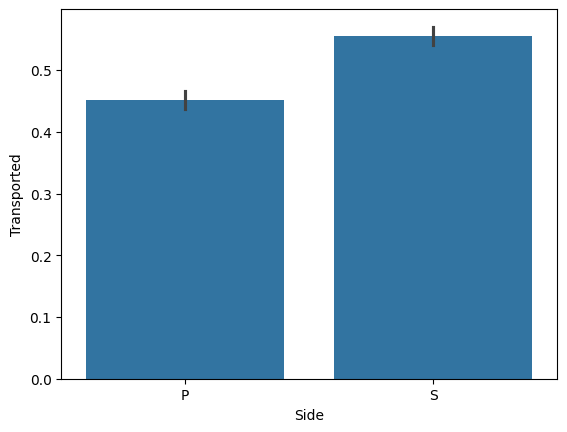

In [40]:
sns.barplot(
    data=train,
    x='Side',
    y='Transported'
)

**Side appears to have some correlation with transported.**

In [41]:
pd.pivot_table(train, index = 'Transported',columns='Deck',values = 'PassengerId' ,aggfunc='count')

Deck,A,B,C,D,E,F,G,T
Transported,,,,,,,,
False,129,207,239,271,563,1565,1238,4
True,127,572,508,207,313,1229,1321,1


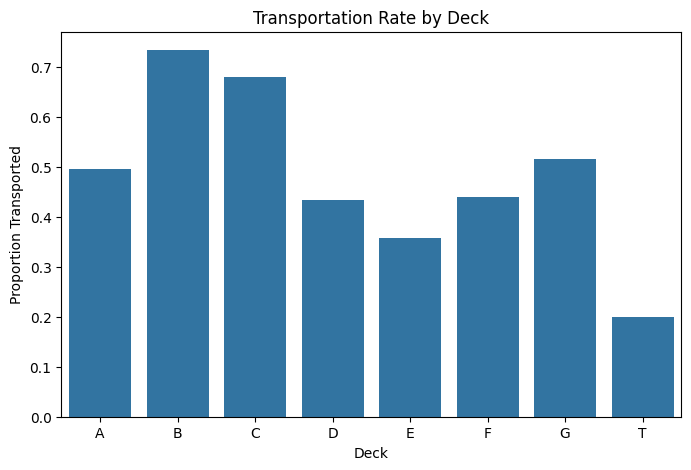

In [42]:
deck_transport = pd.crosstab(
    train['Deck'],
    train['Transported'],
    normalize='index'
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=deck_transport.index,
    y=deck_transport[True]
)

plt.title('Transportation Rate by Deck')
plt.xlabel('Deck')
plt.ylabel('Proportion Transported')

plt.show()

In [43]:
pd.crosstab(train['Deck'], train['Side'])

Side,P,S
Deck,,
A,117,139
B,353,426
C,341,406
D,248,230
E,429,447
F,1438,1356
G,1276,1283
T,4,1


In [44]:
deck_side_transport = pd.crosstab(
    [train['Deck'], train['Side']],
    train['Transported'],
    normalize='index'
)

print(deck_side_transport)

Transported     False     True 
Deck Side                      
A    P       0.564103  0.435897
     S       0.453237  0.546763
B    P       0.325779  0.674221
     S       0.215962  0.784038
C    P       0.419355  0.580645
     S       0.236453  0.763547
D    P       0.596774  0.403226
     S       0.534783  0.465217
E    P       0.657343  0.342657
     S       0.628635  0.371365
F    P       0.589013  0.410987
     S       0.529499  0.470501
G    P       0.551724  0.448276
     S       0.416212  0.583788
T    P       0.750000  0.250000
     S       1.000000  0.000000


## Feature Engineering

#### Feature to create:
- GroupSize
- Deck
- Side
- TotalSpent
- HasSpent

#### Features to keep:

- HomePlanet
- CryoSleep
- Destination
- Age
- VIP
- RoomService
- FoodCourt
- ShoppingMall
- Spa
- VRDeck 

In [45]:
# Creating a pipeline
def feature_engineer(train, test):
    
    train = train.copy()
    test = test.copy()

    # --------------------------------------------------
    # 1. Group
    # --------------------------------------------------
    train['Group'] = train['PassengerId'].str.split('_').str[0]
    test['Group'] = test['PassengerId'].str.split('_').str[0]

    # Calculate GroupSize using both train and test
    all_data = pd.concat(
        [train[['Group']], test[['Group']]],
        ignore_index=True
    )

    group_sizes = all_data['Group'].value_counts()

    train['GroupSize'] = train['Group'].map(group_sizes)
    test['GroupSize'] = test['Group'].map(group_sizes)

    # --------------------------------------------------
    # 2. Cabin → Deck + Side
    # --------------------------------------------------
    train[['Deck', 'CabinNum', 'Side']] = train['Cabin'].str.split(
        '/', expand=True
    )

    test[['Deck', 'CabinNum', 'Side']] = test['Cabin'].str.split(
        '/', expand=True
    )

    # CabinNum is not being used
    train.drop(columns=['CabinNum'], inplace=True)
    test.drop(columns=['CabinNum'], inplace=True)

    # --------------------------------------------------
    # 3. Total spending
    # --------------------------------------------------
    spending_cols = [
        'RoomService',
        'FoodCourt',
        'ShoppingMall',
        'Spa',
        'VRDeck'
    ]

    train['TotalSpend'] = train[spending_cols].sum(axis=1)
    test['TotalSpend'] = test[spending_cols].sum(axis=1)

    # Has the passenger spent anything?
    train['HasSpent'] = (train['TotalSpend'] > 0).astype(int)
    test['HasSpent'] = (test['TotalSpend'] > 0).astype(int)

    # --------------------------------------------------
    # 4. Drop columns we don't want
    # --------------------------------------------------
    drop_cols = [
        'PassengerId',
        'Name',
        'Cabin',
        'Group'
    ]

    train.drop(columns=drop_cols, inplace=True)
    test.drop(columns=drop_cols, inplace=True)

    return train,test

In [46]:
train = pd.read_csv("/kaggle/input/competitions/spaceship-titanic/train.csv")
test = pd.read_csv("/kaggle/input/competitions/spaceship-titanic/test.csv")

In [47]:
df_train, df_test = feature_engineer(train.copy(),test.copy())
df_train.head()

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,GroupSize,Deck,Side,TotalSpend,HasSpent
0,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,False,1,B,P,0.0,0
1,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,True,1,F,S,736.0,1
2,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,False,2,A,S,10383.0,1
3,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,False,2,A,S,5176.0,1
4,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,True,1,F,S,1091.0,1


In [48]:
df_test.head()

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,GroupSize,Deck,Side,TotalSpend,HasSpent
0,Earth,True,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,1,G,S,0.0,0
1,Earth,False,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,1,F,S,2832.0,1
2,Europa,True,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,1,C,S,0.0,0
3,Europa,False,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,1,C,S,7418.0,1
4,Earth,False,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,1,F,S,645.0,1


In [49]:
X = df_train.drop(columns='Transported')
y = df_train['Transported']

### Creating pipeline

In [50]:
numerical_features = X.select_dtypes(include = ['int64', 'float64']).columns

categorical_features = X.select_dtypes(include=['object', 'bool']).columns

In [51]:
print("Numerical:", list(numerical_features))
print("Categorical:", list(categorical_features))

Numerical: ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'GroupSize', 'TotalSpend', 'HasSpent']
Categorical: ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'Side']


In [52]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

numerical_pipeline = Pipeline([
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [53]:
from sklearn.preprocessing import OneHotEncoder

categorical_pipeline = Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('encoder',OneHotEncoder(handle_unknown='ignore',sparse_output= False))
])

In [54]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ('num' , numerical_pipeline,numerical_features),
    ('cat',categorical_pipeline,categorical_features)
])

In [55]:
pipeline  = Pipeline(steps =[
    ('preprocessor' , preprocessor)
])

X_preprocessed = pipeline.fit_transform(X)

In [56]:
print(X_preprocessed)

[[ 0.71194537 -0.33310466 -0.28102673 ...  0.          1.
   0.        ]
 [-0.33403748 -0.16807343 -0.27538657 ...  0.          0.
   1.        ]
 [ 2.03685698 -0.2680006   1.95999765 ...  0.          0.
   1.        ]
 ...
 [-0.1945731  -0.33310466 -0.28102673 ...  0.          0.
   1.        ]
 [ 0.22382004 -0.33310466  0.37636549 ...  0.          0.
   1.        ]
 [ 1.06060632 -0.14233462  2.656871   ...  0.          0.
   1.        ]]


### Model Building

In [57]:
#Creating a baseline using naive bayes
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_preprocessed,y)


GaussianNB()

In [58]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    nb,
    X_preprocessed,
    y,
    cv=cv,
    scoring='accuracy'
)

print("CV Scores:", scores)
print("Mean Accuracy:", scores.mean())

CV Scores: [0.77055779 0.74870615 0.64692352 0.7566168  0.76639816]
Mean Accuracy: 0.737840484756725


In [59]:
# Linear
from sklearn.linear_model import LogisticRegression

# Distance-based
from sklearn.neighbors import KNeighborsClassifier

# Kernel-based
from sklearn.svm import SVC

# Tree-based
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Boosting
from sklearn.ensemble import GradientBoostingClassifier

# XGBoost
from xgboost import XGBClassifier

In [60]:
models = {
    'Logistic Regression' : LogisticRegression(),
    'KNN': KNeighborsClassifier(),
    'svc' : SVC(probability=True),
    'Decision Tree' : DecisionTreeClassifier(random_state=1),
    'Random Forest' : RandomForestClassifier(),
    'XGBoost' : XGBClassifier(random_state=1)
}

for model in models:
    scores = cross_val_score(models[model],X_preprocessed,y,cv=cv,scoring='accuracy')
    print('Model: ',model)
    print("CV Scores:", scores)
    print("Mean Accuracy:", scores.mean())


Model:  Logistic Regression
CV Scores: [0.7947096  0.78378378 0.79700978 0.79228999 0.78078251]
Mean Accuracy: 0.789715131972067
Model:  KNN
CV Scores: [0.77458309 0.76250719 0.76365727 0.76006904 0.76754891]
Mean Accuracy: 0.7656731015470579
Model:  svc
CV Scores: [0.80678551 0.79125934 0.79700978 0.79574223 0.78250863]
Mean Accuracy: 0.7946610984316343
Model:  Decision Tree
CV Scores: [0.74295572 0.72742956 0.74468085 0.73130035 0.72266974]
Mean Accuracy: 0.7338072421024212
Model:  Random Forest
CV Scores: [0.79700978 0.7786084  0.79183439 0.78653625 0.78020713]
Mean Accuracy: 0.7868391884282
Model:  XGBoost
CV Scores: [0.80563542 0.79125934 0.78895917 0.80724971 0.79746835]
Mean Accuracy: 0.7981144011577623


In [61]:
gbc = GradientBoostingClassifier(random_state=1)
scores = cross_val_score(gbc,X_preprocessed,y,cv=cv,scoring='accuracy')
print('Gradient Boosting Classifier')
print("CV Scores:", scores)
print("Mean Accuracy:", scores.mean())

Gradient Boosting Classifier
CV Scores: [0.80046003 0.78608396 0.80391029 0.8164557  0.7853855 ]
Mean Accuracy: 0.7984590961698421


In [62]:
from sklearn.ensemble import VotingClassifier

voting_clf = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression()),
        ('knn', KNeighborsClassifier()),
        ('svc', SVC(probability=True)),
        ('dt', DecisionTreeClassifier(random_state=1)),
        ('rf', RandomForestClassifier()),
        ('xgb', XGBClassifier(random_state=1))
    ],
    voting='soft'
)


## Baseline Model Performance

All models were evaluated using **5-fold Stratified Cross-Validation** with accuracy as the evaluation metric.

| Model | Mean CV Accuracy |
|---|---:|
| XGBoost| 0.7981 |
| SVC | 0.7947 |
| Logistic Regression | 0.7897 |
| Random Forest | 0.7888 |
| KNN | 0.7657 |
| Gaussian Naive Bayes | 0.7378 |
| Decision Tree | 0.7338 |
| **Gradient Boosting Classifier** | **0.7984** |
| Voting Classifier | 0.7932 |


### Tuning Parameters

Tune models using grid search

In [63]:
from sklearn.model_selection import GridSearchCV 


In [64]:
def clf_performance(classifier, model_name):
    print(model_name)
    print('Best Score: ' + str(classifier.best_score_))
    print('Best Parameters: ' + str(classifier.best_params_))

In [65]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [66]:
# gnb = GradientBoostingClassifier(random_state=42)
# param_grid = {
#     'n_estimators': [100, 200, 300],
#     'learning_rate': [0.01, 0.05, 0.1],
#     'max_depth': [2, 3, 4],
#     'min_samples_split': [2, 5],
#     'min_samples_leaf': [1, 2]
# }


In [67]:
# clf_gnb = GridSearchCV(
#     estimator=gnb,
#     param_grid=param_grid,
#     cv=cv,
#     scoring='accuracy',
#     n_jobs=-1,
#     verbose=1
# )

# best_clf_gnb = clf_gnb.fit(X_preprocessed,y)
# clf_performance(best_clf_gnb, 'Gradient Boosting Classifier')

In [68]:
# xgb = XGBClassifier(
#     random_state=42,
#     eval_metric='logloss'
# )

# param_grid = {
#     'n_estimators': [100, 200, 300],
#     'learning_rate': [0.01, 0.05, 0.1],
#     'max_depth': [3, 5, 7],
#     'min_child_weight': [1, 3, 5],
#     'subsample': [0.8, 1.0],
#     'colsample_bytree': [0.8, 1.0]
# }

# clf_xgb = GridSearchCV(
#     estimator=xgb,
#     param_grid=param_grid,
#     cv=cv,
#     scoring='accuracy',
#     n_jobs=-1,
#     verbose=1
# )

# best_clf_xgb = clf_xgb.fit(X_preprocessed,y)
# clf_performance(best_clf_xgb, 'XGBoost')

In [69]:
# lr = LogisticRegression(
#     max_iter=1000,
#     random_state=42
# )
# param_grid_lr = {
#     'C': [0.01, 0.1, 1, 10, 100],
#     'penalty': ['l1', 'l2'],
#     'solver': ['liblinear']
# }

# clf_lr = GridSearchCV(
#     estimator=lr,
#     param_grid=param_grid_lr,
#     cv=cv,
#     scoring='accuracy',
#     n_jobs=-1,
#     verbose=1
# )

# best_clf_lr = clf_lr.fit(X_preprocessed,y)
# clf_performance(best_clf_lr, 'Logistic Regression')

In [70]:
# rf = RandomForestClassifier(
#     random_state=42
# )

# param_grid_rf = {
#     'n_estimators': [100, 200, 300],
#     'max_depth': [None, 10, 20, 30],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4],
#     'max_features': ['sqrt', 'log2']
# }

# grid_search_rf = GridSearchCV(
#     estimator=rf,
#     param_grid=param_grid_rf,
#     cv=cv,
#     scoring='accuracy',
#     n_jobs=-1,
#     verbose=1
# )

# best_clf_rf = grid_search_rf.fit(X_preprocessed,y)
# clf_performance(best_clf_rf, 'Random Forest')

### Best params 

After applying grid search following were the best params for each of the models:
- Gradient Boosted Classifier :  Best Score: 0.80616540199088
Best Parameters: {'learning_rate': 0.05, 'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}

- XGBoost : Best Score: 0.8084670303092064
Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 300, 'subsample': 1.0}

- Logistic Regression: Best Score: 0.7902903736192183
Best Parameters: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}

- Random Forest : Best Score: 0.803059375022747
Best Parameters: {'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}

### Initialising models using params found during grid search

In [71]:
from sklearn.ensemble import (
    GradientBoostingClassifier,
    RandomForestClassifier
)
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Gradient Boosting
gb_model = GradientBoostingClassifier(
    learning_rate=0.05,
    max_depth=4,
    min_samples_leaf=2,
    min_samples_split=2,
    n_estimators=300,
    random_state=42
)

# XGBoost
xgb_model = XGBClassifier(
    colsample_bytree=1.0,
    learning_rate=0.05,
    max_depth=5,
    min_child_weight=3,
    n_estimators=300,
    subsample=1.0,
    random_state=42,
    eval_metric='logloss'
)

# Logistic Regression
lr_model = LogisticRegression(
    C=10,
    penalty='l2',
    solver='liblinear',
    max_iter=2000,
    random_state=42
)

# Random Forest
rf_model = RandomForestClassifier(
    max_depth=30,
    max_features='sqrt',
    min_samples_leaf=2,
    min_samples_split=10,
    n_estimators=100,
    random_state=42
)

In [72]:
tuned_models = {
    "Gradient Boosting" : gb_model,
    "XGBoost" : xgb_model,
    "Logistic Regression" : lr_model,
    "Random Forest" : rf_model
}


In [73]:
#verfifying scores
for name,model in tuned_models.items():
    scores = cross_val_score(
        model,
        X_preprocessed,
        y,
        cv=cv,
        scoring='accuracy',
        n_jobs=-1
    )

    print(f"Model: {name}")
    print(f"CV Scores: {scores}")
    print(f"Mean Accuracy: {scores.mean():.4f}")
    print()

Model: Gradient Boosting
CV Scores: [0.81426107 0.79758482 0.81081081 0.81357883 0.79459148]
Mean Accuracy: 0.8062

Model: XGBoost
CV Scores: [0.81253594 0.79585969 0.81311098 0.82220944 0.7986191 ]
Mean Accuracy: 0.8085

Model: Logistic Regression
CV Scores: [0.79528465 0.7826337  0.79873491 0.79344074 0.78135788]
Mean Accuracy: 0.7903

Model: Random Forest
CV Scores: [0.81713629 0.79873491 0.79815986 0.80552359 0.79574223]
Mean Accuracy: 0.8031



In [74]:
#Ensemble model
from sklearn.ensemble import VotingClassifier

voting_clf = VotingClassifier(
    estimators=[
        ('gb', gb_model),
        ('xgb', xgb_model),
        ('lr', lr_model),
        ('rf', rf_model)
    ],
    voting='soft'
)

In [75]:
scores = cross_val_score(
    voting_clf,
    X_preprocessed,
    y,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)
print(f"Scores for voting classifier: {scores.mean():.4f}")

Scores for voting classifier: 0.8066


### Evaluating on test data

In [76]:
test_preprocessed = pipeline.transform(df_test)

In [77]:
print(test_preprocessed)

[[-0.12484091 -0.33310466 -0.28102673 ...  0.          0.
   1.        ]
 [-0.68269843 -0.33310466 -0.27538657 ...  0.          0.
   1.        ]
 [ 0.15408785 -0.33310466 -0.28102673 ...  0.          0.
   1.        ]
 ...
 [-0.12484091 -0.33310466 -0.28102673 ...  0.          1.
   0.        ]
 [-0.12484091 -0.33310466  1.39848819 ...  0.          1.
   0.        ]
 [ 0.99087413 -0.33310466 -0.28102673 ...  0.          0.
   1.        ]]


In [78]:
gb_model.fit(X_preprocessed,y)

gb_preds = gb_model.predict(test_preprocessed)

In [79]:
print(gb_preds)

[ True False  True ...  True  True  True]


In [80]:
final_data_gb = {'PassengerId': test.PassengerId, 'Transported': gb_preds}
submission_gb = pd.DataFrame(data=final_data_gb)

In [81]:
submission_gb

,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True
...,...,...
4272,9266_02,True
4273,9269_01,True
4274,9271_01,True
4275,9273_01,True


In [82]:
submission_gb.to_csv('submission_gb.csv',index=False)

In [83]:
xgb_model.fit(X_preprocessed,y)
xgb_preds = xgb_model.predict(test_preprocessed).astype(bool)

print(xgb_preds)

final_data_xgb ={'PassengerId': test.PassengerId,'Transported': xgb_preds}
submission_xgb = pd.DataFrame(data = final_data_xgb)

submission_xgb.to_csv('submission_xgb.csv', index=False)

[ True False  True ...  True  True  True]


In [84]:
rf_model.fit(X_preprocessed,y)
rf_preds = rf_model.predict(test_preprocessed)

final_data_rf ={'PassengerId': test.PassengerId,'Transported': rf_preds}
submission_rf = pd.DataFrame(data = final_data_rf)

submission_rf.to_csv('submission_rf.csv', index=False)

In [85]:
lr_model.fit(X_preprocessed,y)
lr_preds = lr_model.predict(test_preprocessed)

final_data_lr = {'PassengerId': test.PassengerId,'Transported': lr_preds}
submission_lr = pd.DataFrame(data = final_data_lr)
submission_lr.to_csv('submission_lr.csv',index=False)

In [86]:
voting_clf.fit(X_preprocessed,y)
voting_preds = voting_clf.predict(test_preprocessed)

final_data_voting ={'PassengerId': test.PassengerId,'Transported': voting_preds}
submission_voting = pd.DataFrame(data = final_data_voting)

submission_voting.to_csv('submission_voting.csv', index=False)